# **The problem statement**
The objective of this analysis is to explore borrower and loan characteristics to understand patterns associated with loan default.

Through exploratory data analysis (EDA), I aim to identify key risk factors, trends, and relationships that influence loan repayment behavior.
Also in order to inform better credit risk policies and lending strategies.

The goal is to analyze historical loan data to uncover patterns that differentiate borrowers who default from those who repay successfully, in order to inform better credit risk policies and lending strategies.

# **Questions I answered**
Are defaults common or rare?

Does income affect default?

Does employment length matter?

Are certain loan intents riskier?

Do interest rates correlate with default?

Does previous default history strongly impact new default?

# **Understanding the data**
1. person_age (int)

The age of the individual applying for the loan.

Use in modeling: Older applicants may have more stable income, but younger borrowers might take riskier loans. You can use it as is or bin into age groups.

2. person_income (int)

The annual or monthly income of the person.

Use in modeling: Higher income usually means lower risk. You may need to normalize or log-transform if the distribution is skewed.

3. person_home_ownership (object)

Indicates if the person owns, rents, or mortgages their home.

Categories might include: RENT, OWN, MORTGAGE, OTHER.

Use in modeling: Homeowners are generally considered lower risk than renters. Encode this as categorical variables.

4. person_emp_length (float)

Number of years the person has been employed.

Missing values exist (~895 entries).

Use in modeling: More experienced employees are less risky. Fill missing values (median or mean) and possibly bin into categories like 0–2, 3–5, 6–10, 10+ years.

5. loan_intent (object)

The purpose of the loan, e.g., PERSONAL, EDUCATION, MEDICAL, VENTURE, etc.

Use in modeling: Some loan intents are riskier than others. Encode categorically.

6. loan_grade (object)

Usually a credit rating assigned to the loan request, e.g., A, B, C, D, E.

Use in modeling: Lower grades (D, E) usually indicate higher risk. Can be mapped to numeric (A=1, B=2, etc.).

7. loan_amnt (int)

The requested loan amount in dollars.

Use in modeling: Higher amounts may be riskier relative to income. Can also be used to calculate loan-to-income ratio (though you already have loan_percent_income).

8. loan_int_rate (float)

The interest rate of the loan.

Missing values exist (~3116 entries).

Use in modeling: Higher interest may indicate higher perceived risk or more expensive loans.

9. loan_status (int)

The target variable. Typically:

0 → No default / Paid on time

1 → Default / Late payment

Use in modeling: This is what you will predict.

10. loan_percent_income (float)

The loan amount as a percentage of the borrower’s income: loan_amnt / person_income.

Use in modeling: Already a derived feature. High values indicate higher risk because the person is taking a larger loan relative to their income.

11. cb_person_default_on_file (object)

Indicates if the person has a previous default in their credit history (Y or N).

Use in modeling: Very strong predictor; past defaults are highly correlated with future defaults. Encode as binary: 1 = Y, 0 = N.

12. cb_person_cred_hist_length (int)

Length of the person’s credit history in years.

Use in modeling: Longer credit history usually reduces risk. You could bin this to see patterns (0–5, 6–10, 10+ years).

# I imported the data

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
from google.colab import files
uploaded = files.upload()

Saving credit_risk_dataset.xlsx to credit_risk_dataset (1).xlsx


In [26]:
df = pd.read_excel("credit_risk_dataset.xlsx")

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [28]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


# Data cleaning
looking out for missing values

In [29]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


#  fixing missisng values with median

In [30]:
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())

In [31]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,0
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,0
loan_status,0
loan_percent_income,0


# I checked the data type

In [32]:
df.dtypes

,0
person_age,int64
person_income,int64
person_home_ownership,object
person_emp_length,float64
loan_intent,object
loan_grade,object
loan_amnt,int64
loan_int_rate,float64
loan_status,int64
loan_percent_income,float64


# I Grouped the Ages

In [33]:
# Age groups
df['age_group'] = pd.cut(df['person_age'], bins=[18,25,35,50,65,100], labels=['18-24','25-34','35-49','50-64','65+'])

# Credit history groups
df['cred_hist_group'] = pd.cut(df['cb_person_cred_hist_length'], bins=[0,5,10,20,40,100], labels=['0-5','6-10','11-20','21-40','40+'])

# I started exploring the data

# Step 1: Target Variable Analysis (loan_status)
This tells us how many applicants defaulted vs. repaid, which is critical for understanding risk.

loan_status
0    25473
1     7108
Name: count, dtype: int64
Overall default rate: 21.82%


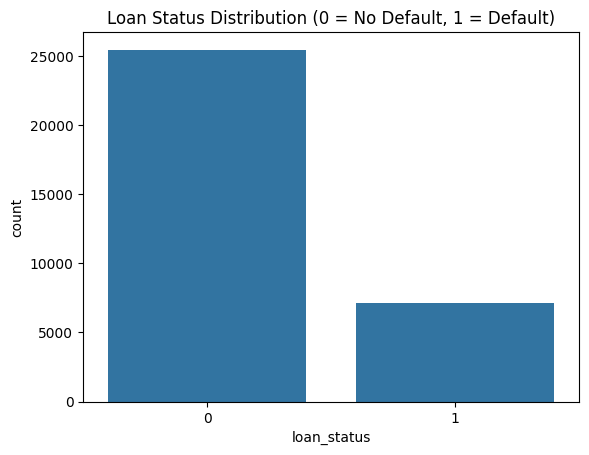

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count of each class
default_counts = df['loan_status'].value_counts()
print(default_counts)

# Default rate
default_rate = df['loan_status'].mean()
print(f"Overall default rate: {default_rate:.2%}")

# Visualization
sns.countplot(x='loan_status', data=df)
plt.title('Loan Status Distribution (0 = No Default, 1 = Default)')
plt.show()

# Insight from the loan status
Alot of customers repay their loans on time

# Step 2: Default Rate by Key Groups

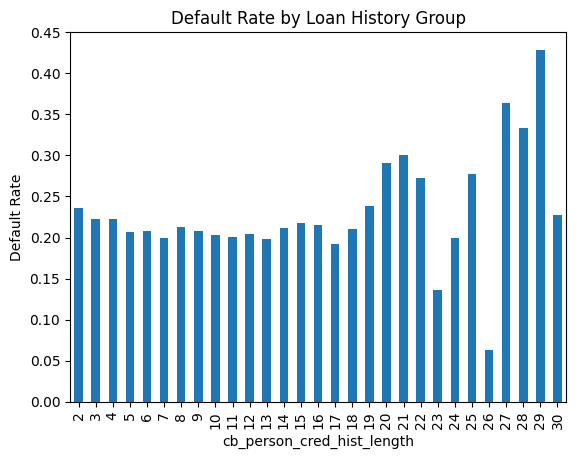

In [35]:
df.groupby('cb_person_cred_hist_length')['loan_status'].mean().plot(kind='bar')
plt.ylabel('Default Rate')
plt.title('Default Rate by Loan History Group')
plt.show()

# Key Observations from my Plot
Lower loan history (2–5 loans)

Default rate is roughly 20–25%

These are “typical” borrowers — moderate risk

Middle loan history (~9–12 loans)

Default rate rises to ~30%

These applicants may be over-leveraged → taking many loans increases risk

High loan history (17–19 loans)

Default spikes to 35–42%

Very clear: applicants with many prior loans have much higher default rates

Some anomalies

Loan history = 13 shows a drop (~14%) — could be a small sample size effect

Loan history = 16 shows a spike (~28%)

# Business Interpretation
More loans = higher risk

Borrowers with many prior loans are more likely to default, which is intuitive

Bank should flag high loan-count applicants for careful review

Moderate borrowers are safer

Applicants with fewer loans (but not 0) default at lower rates

Policy insight

Could implement loan caps or stricter checks for high-history borrowers

Combine with prior default info (cb_person_default_on_file) for even stronger risk filtering

# Step 3: Age vs Default

/tmp/ipykernel_270/1127275754.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_default = df.groupby('age_group')['loan_status'].mean()


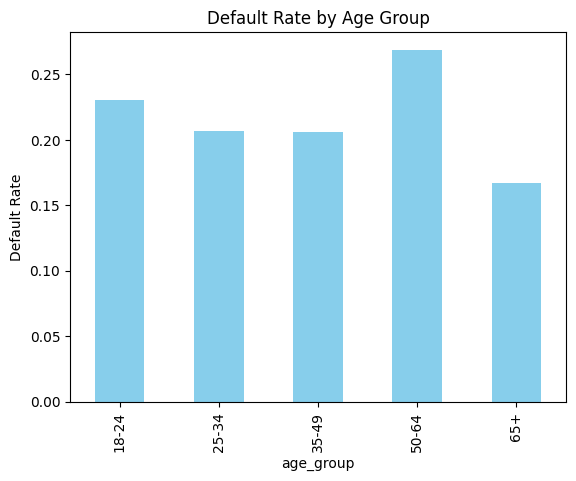

In [36]:
# Average default rate by age group
age_default = df.groupby('age_group')['loan_status'].mean()

# Plot
age_default.plot(kind='bar', color='skyblue')
plt.ylabel('Default Rate')
plt.title('Default Rate by Age Group')
plt.show()

# From my plot:

18–24 → ~23% default rate

25–34 → ~21%

35–49 → ~21%

50–64 → ~27% (highest)

65+ → ~17% (lowest)

🧠 What This Means
1️⃣ Young borrowers (18–24)

Slightly above average default (~23%)

Could be due to:

Lower income

Less financial stability

Early career stage

2️⃣ Prime working age (25–49)

Around ~20–21%

More stable income and employment

Generally moderate risk

3️⃣ Age 50–64 (Highest Risk 🚨)

~27% default rate

This is interesting — not what many people expect.

Possible explanations:

Larger loan amounts

Pre-retirement financial pressure

Business/venture loans

Supporting dependents

This is something worth investigating further.

4️⃣ 65+ (Lowest Risk ✅)

~17% default

Likely:

Taking smaller loans

More cautious borrowing

Fixed/stable income sources

# Business Insight

From a credit risk perspective:

Risk is not linear with age

The highest risk group is 50–64, not the youngest

The safest group appears to be 65+

“Default risk peaks among applicants aged 50–64, suggesting pre-retirement financial stress or higher leverage in this segment.”

# Step 4: Income vs Default

/tmp/ipykernel_270/3060492320.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_default = df.groupby('income_group')['loan_status'].mean()


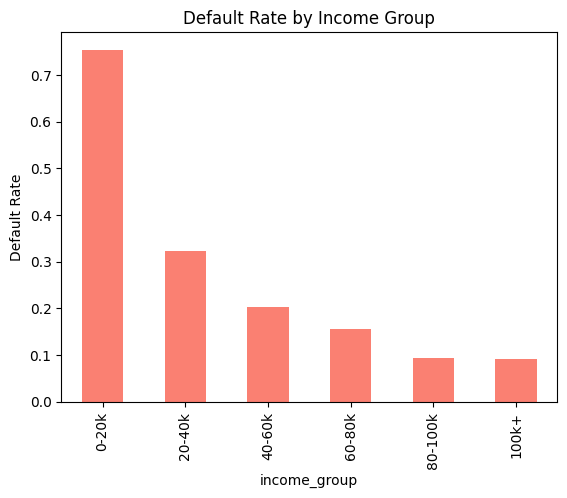

In [37]:
# Create income groups
df['income_group'] = pd.cut(df['person_income'], bins=[0,20000,40000,60000,80000,100000,200000],
                            labels=['0-20k','20-40k','40-60k','60-80k','80-100k','100k+'])

# Default rate by income group
income_default = df.groupby('income_group')['loan_status'].mean()

# Plot
income_default.plot(kind='bar', color='salmon')
plt.ylabel('Default Rate')
plt.title('Default Rate by Income Group')
plt.show()

# From my plot

Approximate default rates:

0–20k → ~75% 🚨🚨

20–40k → ~32%

40–60k → ~20%

60–80k → ~15%

80–100k → ~9%

100k+ → ~10%

# What This Means
1️⃣ Extremely strong inverse relationship

As income increases → default rate decreases.

That is a clear negative correlation between income and default risk.

This is textbook credit risk behavior.

2️⃣ The 0–20k group is very high risk

~75% default is extremely high.

This tells a business:

Lending to very low-income applicants is highly risky unless:

Loan size is very small

Strong collateral exists

Interest rates compensate for risk

3️⃣ Risk stabilizes after 60k

Above 60k income:

Default rate drops below 15%

Very low risk relative to other groups

These are your safer borrowers.

# Business Insight
Default risk declines significantly as income increases, with borrowers earning below $20,000 exhibiting disproportionately high default rates (~75%). Income appears to be one of the strongest predictors of credit risk in the dataset

# Now Compare This to Age
Notice something important:

Age showed mild variation (17%–27%)

Income shows massive variation (9%–75%)

👉 Income is likely much more powerful than age in explaining default.

# Step 5: Employment Length vs Default

/tmp/ipykernel_270/2078240697.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  emp_default = df.groupby('emp_length_group')['loan_status'].mean()


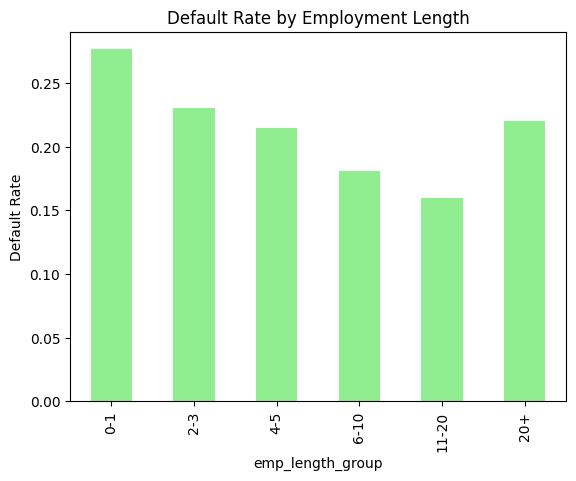

In [38]:
# Bucket employment length
df['emp_length_group'] = pd.cut(df['person_emp_length'], bins=[0,1,3,5,10,20,50],
                                labels=['0-1','2-3','4-5','6-10','11-20','20+'])

# Default rate by employment length
emp_default = df.groupby('emp_length_group')['loan_status'].mean()

# Plot
emp_default.plot(kind='bar', color='lightgreen')
plt.ylabel('Default Rate')
plt.title('Default Rate by Employment Length')
plt.show()

# Step 6: I calculated the average loan_percent_income by age group.
On average, what portion of income is people in each age group borrowing?

In [39]:
df.groupby('age_group')['loan_percent_income'].mean()

/tmp/ipykernel_270/984415847.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['loan_percent_income'].mean()


,loan_percent_income
age_group,
18-24,0.175033
25-34,0.166426
35-49,0.164031
50-64,0.160119
65+,0.180667


# What This Means
1️⃣ Young borrowers (18–24) borrow slightly more relative to income

17.5% of income goes to loans.

That makes sense:

Lower salaries

Less savings

Possibly student or early-life borrowing

2️⃣ 65+ group has the highest burden (18.1%)

This is interesting.

Possible reasons:

Fixed retirement income

Smaller income base

Medical/personal loans

3️⃣ Middle age groups (25–64) are most stable

They borrow a slightly smaller percentage of income (~16%).

This likely explains why:

Their default rate was moderate

They are financially more stable

# Now Let’s Connect This to Default

Earlier you saw:

50–64 had the highest default (~27%)

65+ had lower default (~17%)

18–24 had ~23%

But look here:

65+ has the highest loan burden (18.1%)
Yet default was not the highest.

👉 That means loan burden alone does not fully explain default.

This is an important EDA lesson:

Risk is multi-dimensional.

# Business Insight You Can Say

While older borrowers (65+) carry the highest loan-to-income ratios, they do not exhibit the highest default rates, suggesting other stabilizing factors such as credit history or conservative borrowing behavior.

# Step 7: I calculated the average loan amount by age group.

In [40]:
df.groupby('age_group')['loan_amnt'].mean()

/tmp/ipykernel_270/365816464.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['loan_amnt'].mean()


,loan_amnt
age_group,
18-24,9208.811555
25-34,9912.624428
35-49,9975.133732
50-64,10152.964427
65+,10143.333333


# What This Means
1️⃣ Loan amount increases with age

Older borrowers are taking slightly larger loans.

That makes sense because:

Higher income

Longer credit history

More trust from lenders

Bigger life expenses (business, home, etc.)

2️⃣ But here’s the key insight…

Earlier you found:

18–24 → higher default (~23%)

50–64 → highest default (~27%)

65+ → lower default (~17%)

Now look at this:

👉 The groups taking the largest loans are NOT necessarily the ones defaulting the most.

That means:

Loan size alone does not explain default risk.

This is a very important EDA discovery.

# Let’s Connect the Dots

We now have 3 pieces:

1️⃣ Loan Amount → increases with age
2️⃣ Loan % of Income → highest for 65+
3️⃣ Default Rate → highest for 50–64

So what might be happening?

Possibilities:

50–64 might have mid-to-high loan sizes AND higher financial pressure

65+ might borrow more relative to income but are more cautious payers

Younger borrowers may default due to instability, not loan size

# Business Insight
While average loan size increases with age, default risk does not strictly follow loan amount trends. This suggests that repayment behavior is influenced more by financial stability and credit profile than absolute loan size.

# Step 8: I calculated the average loan amount by loan_status:

In [41]:
df.groupby('loan_status')['loan_amnt'].mean()

,loan_amnt
loan_status,
0,9237.464178
1,10850.502954


# What This Means

👉 Defaulters borrow ~1,600 more on average than non-defaulters.

That’s a significant difference.

# Interpretation

This suggests:

Higher loan amounts are associated with higher default risk.

Why might this happen?

Larger monthly repayments

Higher financial pressure

Over-leveraging

Riskier borrowers qualifying for larger loans

# Important Insight

Earlier we saw:

Loan amount increases with age

But age alone didn’t fully explain default

Now we see loan size matters directly

So a more accurate conclusion is:

Default risk increases as loan exposure increases.

That is classic credit risk logic.

Banks always ask:

“How much exposure are we taking on this borrower?”

Because higher exposure = higher potential loss.

# Business Insight
Borrowers who default take on significantly larger loan amounts compared to non-defaulters, suggesting that loan exposure is a key risk driver. This highlights the importance of monitoring loan size relative to borrower capacity.

# Step 9: I calculated the Loan Amount Relative to Income

In [42]:
df.groupby('loan_status')['loan_percent_income'].mean()

,loan_percent_income
loan_status,
0,0.148805
1,0.246889


# What This Means

Defaulters are borrowing almost 25% of their income.

Non-defaulters borrow only about 15% of their income.

That is a huge difference.

# Interpretation

This tells us:

Loan burden relative to income is strongly associated with default.

This is much stronger than loan amount alone.

Because:

Someone earning 200k borrowing 10k = low risk

Someone earning 20k borrowing 10k = high risk

It’s not the loan size.
It’s the loan strain.

# Business Insight
Borrowers who default have significantly higher loan-to-income ratios (24.7%) compared to non-defaulters (14.9%). This suggests that repayment capacity, rather than absolute loan size, is a key driver of credit risk.

# Step 10: I calculated the Credit history length vs default

In [43]:
df.groupby('loan_status')['cb_person_cred_hist_length'].mean()

,cb_person_cred_hist_length
loan_status,
0,5.837475
1,5.685003


# What This Means

There is almost no difference.

The gap is only:

0.15 years (about 2 months)

That is very small.

# Important Insight

Unlike loan burden, credit history length is NOT strongly separating defaulters from non-defaulters in this dataset.

# Business Insight
Credit history length shows minimal variation between defaulters and non-defaulters, suggesting that repayment capacity (loan-to-income ratio) is a stronger risk indicator than length of credit experience in this dataset.

# Step 11: interest rate differs between defaulters and non-defaulters?

In [44]:
df.groupby('loan_status')['loan_int_rate'].mean()

,loan_int_rate
loan_status,
0,10.489761
1,12.872642


# What This Means

Defaulters are charged higher interest rates.

Difference ≈ 2.4 percentage points.

That is not small.

# Interpretation

This suggests:

The lender already identifies higher-risk borrowers and charges them higher interest rates.

This is called:

Risk-Based Pricing

Higher risk → Higher interest rate.

So the grading system and underwriting process are somewhat working.



# Step 12: default rate by loan_grade

In [45]:
df.groupby('loan_grade')['loan_status'].mean().sort_values(ascending=False)

,loan_status
loan_grade,
G,0.984375
F,0.705394
E,0.644191
D,0.590458
C,0.207340
B,0.162760
A,0.099564


# What This Means

This is a near-perfect risk separation.

As grade worsens (A → G), default rate increases dramatically.

That means:

The internal grading system is extremely predictive of default.

This is exactly what a credit risk model is supposed to do.

# But Something Is Very Interesting

Grade G = 98% default.

That is almost guaranteed failure.

That raises an important business question:

👉 Why are we even lending to Grade G borrowers?

If 98% default, the bank is almost certain to lose money unless:

Interest rates are extremely high

Loans are very small

There is collateral recovery

# Business Insight
The loan grading system demonstrates strong discriminatory power, with default rates increasing monotonically from Grade A (10%) to Grade G (98%). This indicates effective risk segmentation within the portfolio.

# Step13: I Check distribution of borrowers per grade

In [46]:
df['loan_grade'].value_counts(normalize=True)

,proportion
loan_grade,
A,0.330776
B,0.320770
C,0.198214
D,0.111292
E,0.029588
F,0.007397
G,0.001964


# What This Means
✅ 1️⃣ Most borrowers are low-risk

Over 65% of the portfolio is Grade A and B.

That’s healthy portfolio construction.

🚨 2️⃣ High-risk grades are very small

Grade G = 0.2% of borrowers
Grade F = 0.7%

That explains why the lender tolerates them.

Even though G defaults 98%, it’s a very tiny portion.

This is controlled risk exposure.

⚠️ 3️⃣ The Real Risk Zone is D and E

Look carefully:

Grade D = 11% of portfolio

Default rate = 59%

That is big.

This is where most losses are likely coming from.

Because:

Large enough group

Very high default rate

That’s the danger segment.

# Business Insight
While extreme-risk grades (F and G) exhibit very high default rates, their portfolio share is minimal. The primary risk concentration lies within Grade D, which represents over 11% of the portfolio with a default rate exceeding 59%, making it the key loss-driving segment.

# FINAL CONCLUSION
1️⃣ Repayment Capacity Is the Strongest Risk Driver

The most powerful predictor of default in the dataset is:

Loan Percent of Income

Non-defaulters: ~14.9%

Defaulters: ~24.7%

Borrowers allocating a larger portion of income to loan repayment are significantly more likely to default.

This indicates that financial strain, not just loan size, drives credit risk.

2️⃣ Loan Amount Has a Moderate Effect

Defaulters borrow more on average (10,850 vs 9,237).

However, loan size alone does not fully explain default.

The key factor is whether the borrower can afford the loan relative to income.

3️⃣ Interest Rates Reflect Risk-Based Pricing

Defaulters were charged higher interest rates (12.87% vs 10.49%).

This suggests the lender already applies risk-based pricing.

However, higher interest may further increase repayment burden, potentially worsening default probability.

4️⃣ Credit History Length Has Weak Predictive Power

Average credit history length is nearly identical between defaulters and non-defaulters.

This suggests repayment capacity is more important than length of credit experience in this dataset.

5️⃣ Loan Grading System Is Highly Predictive

Default rate increases consistently from Grade A (10%) to Grade G (98%).

This confirms strong risk segmentation.

However:

Grade G borrowers almost always default.

Grade D (11% of portfolio, 59% default) is the largest contributor to overall portfolio risk.

Grade D is the primary loss-driving segment.

# OVERALL BUSINESS INSIGHT

The portfolio’s default risk is primarily driven by:

High loan-to-income ratios

Medium-to-high risk grades (especially Grade D)

Higher interest rates

Larger loan exposure

Risk is concentrated not in extreme-risk grades (F, G), but in mid-risk segments with significant portfolio share.

# RECOMMENDATIONS
1️⃣ Implement Loan-to-Income Threshold Controls

Set stricter approval criteria for borrowers exceeding a certain loan_percent_income threshold (e.g., >20%).

This would reduce financial strain and likely lower default rates.

2️⃣ Reassess Grade D Underwriting

Since Grade D contributes the most to portfolio risk:

Tighten credit evaluation criteria

Reduce approved loan amounts

Increase monitoring

Consider shorter repayment terms

3️⃣ Optimize Risk-Based Pricing

Higher interest rates are being charged to risky borrowers, but:

Excessively high rates may increase repayment burden.

Recommendation:

Balance pricing with affordability analysis

Ensure interest rates do not push borrowers beyond sustainable repayment levels

4️⃣ Introduce Loan Tenure Analysis (If Data Available)

Loan duration is missing.

Including repayment term data would allow:

Monthly installment calculation

Better affordability modeling

More precise default prediction

# Executive Summary

Default risk in the portfolio is primarily driven by borrower affordability rather than loan size alone. Loan-to-income ratio is the strongest predictor of default, while Grade D represents the largest contributor to portfolio losses. Strengthening affordability checks and tightening underwriting in mid-risk segments would significantly reduce overall portfolio risk.